In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *
from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *

# from pklib.rl import *


In [2]:
from stable_baselines3 import PPO, A2C, DDPG, DQN, SAC
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
import pandas as pd
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.logger import configure

import numpy as np
import gymnasium as gym  # Use Gymnasium instead of gym
from gymnasium.spaces import Discrete, Box
import json
import pickle

2024-09-11 20:41:47.121915: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-11 20:41:47.129876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-11 20:41:47.139281: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-11 20:41:47.142005: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-11 20:41:47.148989: I tensorflow/core/platform/cpu_feature_guar

In [3]:
?TradingEnv

Object `TradingEnv` not found.


In [4]:
def load_data(exchange, asset, quote, nhours):
    """
    Load and resample candle data.

    Parameters:
    exchange (str): Exchange name (e.g., 'binance').
    asset (str): Asset symbol (e.g., 'BTC').
    quote (str): Quote currency (e.g., 'USDT').
    nhours (int): Number of hours for the timeframe (e.g., 8 for 8-hour candles).

    Returns:
    pd.DataFrame: Resampled candle data.
    """
    df = load_candles(exchange, asset, quote, '1h')
    df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
    return df

def create_indicators(df):
    """
    Create technical indicators.

    Parameters:
    df (pd.DataFrame): Candle data.
    nhours (int): Number of hours for the timeframe.

    Returns:
    pd.DataFrame: DataFrame with technical indicators.
    """
    # params = {'conversion_periods': 30, 'base_periods': 60, 'lagging_span2_periods': 120, 'displacement': 20}
    # params = {k: int(v * (24/nhours)) for k, v in params.items()}
    params = {'conversion_periods': 110, 'base_periods': 301, 'lagging_span2_periods': 250, 'displacement': 180}

    df_indicators = ichimoku_cloud_indicator(df, params, add_to_original=False
        ).join(df[['high', 'low', 'close', 'open']]
        ).join(create_moving_average_features(
            df, ema_periods=[50, 100],
            sma_periods=[50, 100]
        ))
    return df_indicators

def create_features(df_indicators):
    """
    Create comparison features.

    Parameters:
    df_indicators (pd.DataFrame): DataFrame with technical indicators.

    Returns:
    pd.DataFrame: DataFrame with comparison features.
    """
    compare_columns = [
        ('tenkan', 'kijun', 'close','low'), 
        ('kumo_upper', 'kumo_lower', 'open'), 
        # ('lead_span_A', 'lead_span_B', 'close'),
        # ('sma_50', 'sma_100', 'close'),
        # ('ema_50', 'ema_70', 'close'),
    ]
    df_comp_features = create_comparison_features(df_indicators, compare_columns)
    return df_comp_features

def split_dataframes(dataframes, train_size=0.7):
    """
    Split the input dataframes into training and testing sets.

    Parameters:
    dataframes (list): List of pandas DataFrames to split.
    train_size (float): Proportion of the data to use for training (default is 0.7).

    Returns:
    tuple: (train_dfs, test_dfs) Lists of DataFrames for training and testing.
    """
    train_dfs = []
    test_dfs = []

    for df in dataframes:
        # Calculate the split index
        split_index = int(len(df) * train_size)
        
        # Split the DataFrame
        train_df = df.iloc[:split_index]
        test_df = df.iloc[split_index:]
        
        # Append to the respective lists
        train_dfs.append(train_df)
        test_dfs.append(test_df)

    return train_dfs, test_dfs




# Now you can use these split dataframes for training and testing

# df_comp_features = create_comparison_features(df_indicators, compare_columns)
# # percent_diff_thresholds = [-10, -5,-3,-1, 0, 2, 5, 10]
# # df_percent_diffs = create_signed_difference_features_multi(df_indicators,[
# #             ('close', 'tenkan', percent_diff_thresholds),
# #             ('close', 'kijun', percent_diff_thresholds),
# #             ('tenkan', 'kijun', percent_diff_thresholds),
# #             # ('close', 'ema_21', percent_diff_thresholds),
# #             # ('close', 'ema_14', percent_diff_thresholds),
# #             # ('close', 'ema_7', percent_diff_thresholds),
# #             # ('ema_7', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'close', percent_diff_thresholds),
# #             # ('ema_14', 'ema_21', percent_diff_thresholds),
# #             # ('ema_21', 'ema_50', percent_diff_thresholds),
# #             # ('ema_7', 'ema_21', percent_diff_thresholds),
# #         ])


# # df_percent_diffs, _ = remove_highly_correlated_features(df_percent_diffs, threshold=0.7)

# df_features = df_comp_features#.join(df_percent_diffs).dropna()
# # df_features, features_to_drop = remove_highly_correlated_features(df_features, threshold=0.7)
# # print(f'features_to_drop:')
# # pprint(features_to_drop)


In [100]:
class TradingEnv(gym.Env):
    def __init__(self, df, logprice, lookback_window_size=10, trading_mode='both', verbosity=0):
        super(TradingEnv, self).__init__()
        
        self.df = df
        self.logprice = logprice
        self.lookback_window_size = lookback_window_size
        self.trading_mode = trading_mode  # 'long_only', 'short_only', or 'both'
        self.verbosity = verbosity  # Verbosity level: 0 = no logs, 1 = essential logs, 2 = detailed logs
        
        self.current_step = 0
        self.entry_logprice = None
        self.cumulative_pnl = 0
        self.num_positions = 0
        self.position = 0  # 1 = long, 0 = no position, -1 = short

        # Define action space based on trading mode
        if self.trading_mode == 'long_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = long
        elif self.trading_mode == 'short_only':
            self.action_space = Discrete(2)  # 0 = hold, 1 = short
        else:  # 'both'
            self.action_space = Discrete(4)  # 0 = hold, 1 = long, 2 = short, 3 = close position

        # Observation space: OHLCV + technical indicators + entry price + position (flattened lookback period + 2 additional features)
        obs_space_shape = (lookback_window_size * len(self.df.columns) + 1,)
        self.observation_space = Box(low=-np.inf, high=np.inf, shape=obs_space_shape, dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        # Ensure enough data for the lookback window
        self.current_step = self.lookback_window_size

        self.entry_logprice = None
        self.cumulative_pnl = 0  # Reset cumulative PnL at the start of each episode
        self.position = 0  # Reset position
        self.num_positions = 0
        self.entry_step = None

        # Get the starting index for the lookback window (ensure it's valid)
        start_index = max(0, self.current_step - self.lookback_window_size)
        initial_observation = self.df.iloc[start_index:self.current_step].values

        # Pad the history if there are fewer observations than the lookback size
        if len(initial_observation) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(initial_observation), len(self.df.columns)))
            initial_observation = np.vstack((padding, initial_observation))

        # Return the initial flattened observation (1D array)
        # The 'info' dictionary is returned for compatibility with Gym environments
        return np.hstack([initial_observation.flatten(),[0]]).astype(np.float32), {'cumulative_pnl': self.cumulative_pnl}

    def step(self, action):
        current_logprice = self.logprice.iloc[self.current_step]
        reward = 0
        pnl = 0
        trade_info = {}

        if self.verbosity >= 1:
            print(f"Step: {self.current_step}, Action: {action}, Position: {self.position}, Cumulative PnL: {self.cumulative_pnl}")

        # Handle actions based on trading mode
        if self.trading_mode == 'long_only':
            if action == 1 and self.position == 0:  # Open long position
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")
            elif action == 0 and self.position == 1:  # Close long position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed long position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'short_only':
            if action == 1 and self.position == 0:  # Open short position
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")
            elif action == 0 and self.position == -1:  # Close short position
                if self.entry_logprice is not None:  # Check if entry price is set
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed short position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        elif self.trading_mode == 'both':
            if action == 1 and self.position != 1:  # Open or switch to long
                if self.position == -1 and self.entry_logprice is not None:  # Close short position first
                    pnl = self.entry_logprice - current_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': -1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from short to long. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = 1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened long position at {current_logprice}")

            elif action == 2 and self.position != -1:  # Open or switch to short
                if self.position == 1 and self.entry_logprice is not None:  # Close long position first
                    pnl = current_logprice - self.entry_logprice
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': 1,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Switched from long to short. PnL: {pnl}")
                self.entry_logprice = current_logprice
                self.position = -1
                self.entry_step = self.current_step
                if self.verbosity >= 2:
                    print(f"Opened short position at {current_logprice}")

            elif action == 3 and self.position != 0:  # Close position
                if self.entry_logprice is not None:  # Ensure entry price is set
                    pnl = self.position * (current_logprice - self.entry_logprice)
                    self.cumulative_pnl += pnl  # Accumulate PnL
                    self.num_positions += 1
                    trade_info = {
                        'trade_info': {
                            'entry_step': self.entry_step,
                            'exit_step': self.current_step,
                            'position': self.position,
                            'pnl': pnl
                        }
                    }
                    if self.verbosity >= 2:
                        print(f"Closed position. PnL: {pnl}")
                    self.position = 0
                    self.entry_step = None

        # Move to the next step
        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1  # End of data
        truncated = False

        # Handle termination case with open position
        if terminated and self.position != 0 and self.entry_logprice is not None:
            pnl = self.position * (current_logprice - self.entry_logprice)
            self.cumulative_pnl += pnl  # Accumulate PnL
            trade_info = {
                'trade_info': {
                    'entry_step': self.entry_step,
                    'exit_step': self.current_step,
                    'position': self.position,
                    'pnl': pnl
                }
            }
            if self.verbosity >= 2:
                print(f"Terminating with open position. Final PnL: {pnl}")
            self.position = 0  # Close position

        # Calculate reward as pnl or penalize if no position
        reward = pnl

        # Get the next observation
        obs = self._next_observation()

        # Return observation, reward, termination info, and trade details
        info = {
            'position': self.position,
            'cumulative_pnl': self.cumulative_pnl,
            **trade_info
        }

        return obs, reward, terminated, truncated, info

    def _next_observation(self):
        # Handle edge cases where the current step is less than the lookback window size
        start_index = max(0, self.current_step - self.lookback_window_size)
        frame = self.df.iloc[start_index:self.current_step]

        # If the lookback window is smaller than the full lookback size, pad with earlier rows
        if len(frame) < self.lookback_window_size:
            padding = np.zeros((self.lookback_window_size - len(frame), len(self.df.columns)))
            frame = np.vstack((padding, frame.values))
        else:
            frame = frame.values

        # Return flattened lookback window and append position and entry price
        return np.hstack([frame.flatten(), [self.position]]).astype(np.float32)
    
    def render(self, mode="human"):
        # Print relevant information about the environment (for debugging purposes)
        print(f"Step: {self.current_step}, Position: {self.position}, Cumulative PnL: {self.cumulative_pnl:.2f}")



In [62]:
from stable_baselines3.common.callbacks import BaseCallback

class PnLLoggingCallback(BaseCallback):
    """
    Custom callback for logging the cumulative PnL at the end of each episode in a vectorized environment.
    """
    def __init__(self, verbose=1):
        super(PnLLoggingCallback, self).__init__(verbose)
        self.episode_rewards = 0

    def _on_step(self) -> bool:
        # Add the reward from this step to the total episode reward
        self.episode_rewards += self.locals['rewards'][0]

        # Check if the episode is done
        done = self.locals['dones'][0]
        if done:
            info = self.locals['infos'][0]
            cumulative_pnl = info['cumulative_pnl']
            num_collected_steps = self.locals['num_collected_steps']
            num_collected_episodes = self.locals['num_collected_episodes']
            # Properly access the cumulative_pnl from the vectorized environment
            # cumulative_pnl = self.training_env.get_attr('cumulative_pnl', 0)[0]  # Get from the first env (index 0)
        
            # Log the cumulative PnL and total episode rewards
            if self.verbose > 0:
                print(f"{num_collected_episodes} Episodes | {num_collected_steps} steps finished. Cumulative PnL: {cumulative_pnl:.2f}, Total Reward: {self.episode_rewards:.2f}")
            
            # Reset the episode rewards for the next episode
            self.episode_rewards = 0
            
            # Render the environment (if needed)
            # self.training_env.env_method('render')

        return True  # Continue training

class EpisodeLoggingCallback(BaseCallback):
    def __init__(self, n_episodes, verbose=0):
        super(EpisodeLoggingCallback, self).__init__(verbose)
        self.n_episodes = n_episodes
        self.episode_count = 0

    def _on_step(self) -> bool:
        # Check if a new episode has started
        done_array = self.locals["dones"]
        if any(done_array):
            
            info = self.locals['infos'][0]
            cumulative_pnl = info['cumulative_pnl']
            if self.verbose > 0:
                print(f"Episode {self.episode_count} finished. Cumulative PnL: {cumulative_pnl:.2f}")
        
            self.episode_count += 1
        # Stop training if the number of episodes is reached
        return self.episode_count < self.n_episodes


In [104]:

# Parameters
exchange = 'binance'; asset = 'BTC'; quote = 'USDT'; nhours = 8

# lookback_window_size = int(24/nhours) * 2
lookback_window_size = 2
# Load data and create features
df = load_data(exchange, asset, quote, nhours).ffill()
df_indicators = create_indicators(df)
df_features = create_features(df_indicators)

# Remove NaNs from features
df_features = df_features.dropna() * 0.3 + 0.2

# Use df_features index to filter df and df_indicators
df = df.loc[df_features.index]
df_indicators = df_indicators.loc[df_features.index]

# Create log prices
log_prices = np.log(df['close']).ffill()

# Verify all dataframes have the same length
assert len(df) == len(df_indicators) == len(df_features) == len(log_prices), "Dataframe lengths do not match"
# Create log prices

# Split all dataframes at once
(train_df, train_indicators, train_features, train_log_prices), \
(test_df, test_indicators, test_features, test_log_prices) = split_dataframes([df, df_indicators, df_features, log_prices], train_size=0.7)

trading_mode = 'long_only'# Wrap the environment

# env = DummyVecEnv([lambda: TradingEnv(train_features, train_log_prices, lookback_window_size=lookback_window_size)])
# # Use VecNormalize to normalize both observations and rewards
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)
train_env = TradingEnv(train_features, train_log_prices, lookback_window_size=lookback_window_size, trading_mode=trading_mode, verbosity=0)
check_env(train_env)
# env = DummyVecEnv([lambda: env])
obs_n = train_env.observation_space.shape[0]
act_n = train_env.action_space.n
net_arch = [64, 64]
policy_kwargs = dict(policy_kwargs=dict(net_arch=net_arch))
# model = DQN("MlpPolicy", env, verbose=2, learning_rate=0.0001, policy_kwargs=policy_kwargs )
# Optional: Check the environment (this will give warnings if something is incompatible)


# Define DQN model
model = DQN(
    "MlpPolicy",      # Use Multi-Layer Perceptron Policy
    train_env,              # Pass your trading environment
    # learning_rate=0.3,
    # buffer_size=50000, 
    # learning_starts=0,
    # batch_size=32,
    # tau=1.0,
    # gamma=0.995,
    target_update_interval=1000,
    train_freq=(1, "episode"),
    # train_freq=(5000, "step"),
    # gradient_steps=1,
    # exploration_fraction=0.1,  # Fraction of the training where exploration is active
    # exploration_initial_eps=0.3,  # Initial epsilon for exploration
    # exploration_final_eps=0.001,  # Final epsilon for exploration
    verbose=0
)

# Set up tensorboard logging
# new_logger = configure('tensorboard_logs/', ["stdout", "tensorboard"])
# model.set_logger(new_logger)

# Create the custom callback
pnl_logging_callback = PnLLoggingCallback(verbose=1)

# Specify the number of episodes you want to train for
n_episodes = 20

# Initialize the callback
episode_logging_callback = EpisodeLoggingCallback(n_episodes=n_episodes, verbose=1)

# Train the model for a large number of timesteps but rely on the callback to stop after the desired number of episodes
# model.learn(total_timesteps=1000000, callback=episode_logging_callback)

# Train the DQN model with the custom callback
# total_timesteps = 10 * len(train_df)
model.learn(total_timesteps=100000, callback=[episode_logging_callback])

# Save the trained model
model.save("dqn_custom_policy")

# env.save("vec_normalize.pkl")
# tensorboard --logdir tensorboard_logs/

Episode 0 finished. Cumulative PnL: -0.41
Episode 1 finished. Cumulative PnL: 1.58
Episode 2 finished. Cumulative PnL: 1.26
Episode 3 finished. Cumulative PnL: 1.56
Episode 4 finished. Cumulative PnL: 1.25
Episode 5 finished. Cumulative PnL: 1.15
Episode 6 finished. Cumulative PnL: 1.56
Episode 7 finished. Cumulative PnL: 1.35
Episode 8 finished. Cumulative PnL: 1.59
Episode 9 finished. Cumulative PnL: 1.30
Episode 10 finished. Cumulative PnL: 1.61
Episode 11 finished. Cumulative PnL: 0.97
Episode 12 finished. Cumulative PnL: 1.40
Episode 13 finished. Cumulative PnL: 1.74
Episode 14 finished. Cumulative PnL: 1.57
Episode 15 finished. Cumulative PnL: 1.66
Episode 16 finished. Cumulative PnL: 1.42
Episode 17 finished. Cumulative PnL: 2.27
Episode 18 finished. Cumulative PnL: 1.43


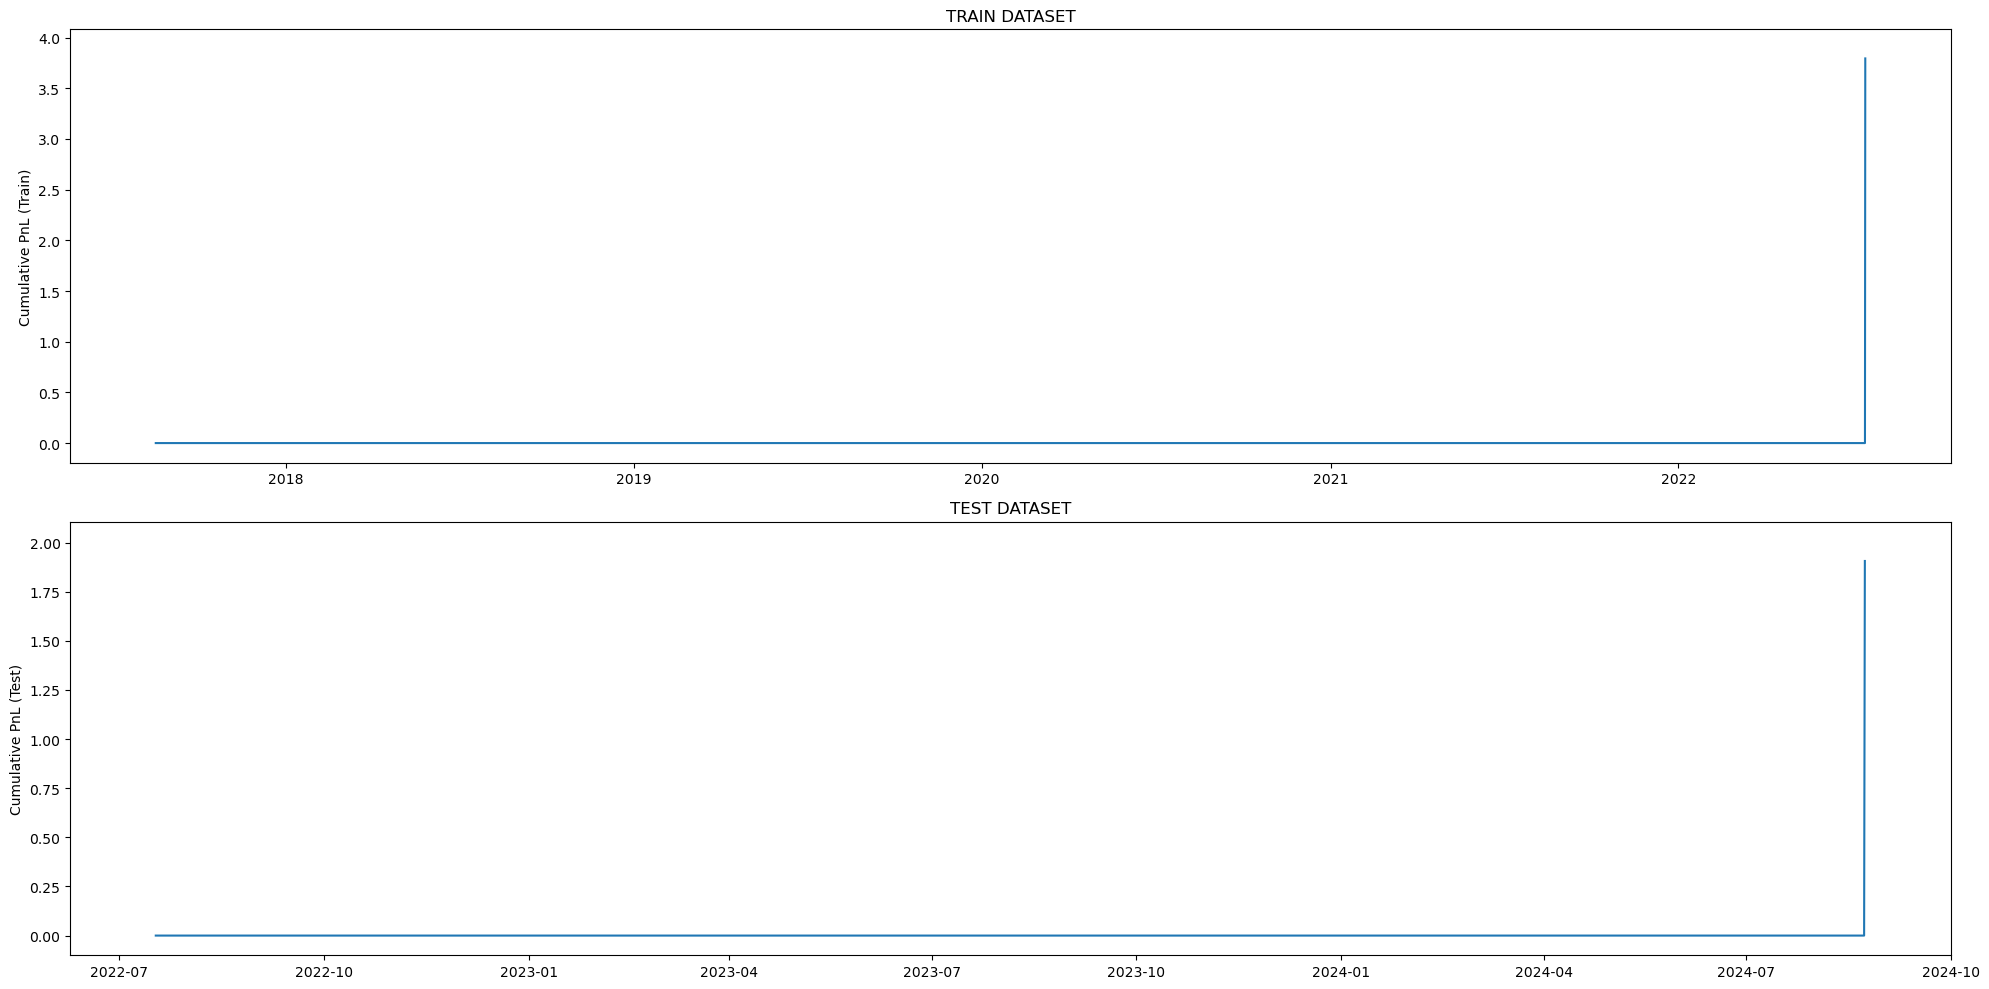

In [105]:

# model.save("dqn_custom_policy")
train_env = TradingEnv(train_features, train_log_prices, lookback_window_size=lookback_window_size, trading_mode=trading_mode, verbosity=0)

train_backtest_df,train_trades_df = perform_backtest(model, train_env)

test_backtest_df,test_trades_df = None, None
if(len(test_df) > 0):
    test_env = TradingEnv(test_features, test_log_prices, lookback_window_size=lookback_window_size, trading_mode=trading_mode)
    test_backtest_df,test_trades_df = perform_backtest(model, test_env)

fig, ax1, ax2 = plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df, test_trades_df)

In [15]:
def plot_cumulative_pnl(train_backtest_df, train_trades_df, test_backtest_df=None, test_trades_df=None):
    """
    Function to plot cumulative PnL for training and testing datasets on two separate axes.
    
    Parameters:
    - train_backtest_df: DataFrame containing the backtest results for the training dataset.
    - train_trades_df: DataFrame containing the trade details for the training dataset.
    - test_backtest_df: DataFrame containing the backtest results for the testing dataset (optional).
    - test_trades_df: DataFrame containing the trade details for the testing dataset (optional).
    """
    
    # Create a single figure with two separate axes (not sharing x-axis)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

    # Plot for the training dataset
    ax1.plot(train_backtest_df['cumulative_pnl'].apply(np.expm1))  # Plot cumulative PnL for training
    ax1.plot(train_trades_df.exit_index, train_trades_df['pnl'].cumsum().apply(np.expm1), alpha=0.3)  # Plot trade PnL
    ax1.set_ylabel('Cumulative PnL (Train)')
    ax1.set_title('TRAIN DATASET')  # Add a title for the training plot

    # Plot for the testing dataset (if provided)
    if test_backtest_df is not None:
        ax2.plot(test_backtest_df['cumulative_pnl'].apply(np.expm1))  # Plot cumulative PnL for testing
        ax2.plot(test_trades_df.exit_index, test_trades_df['pnl'].cumsum().apply(np.expm1), alpha=0.3)  # Plot trade PnL
        ax2.set_ylabel('Cumulative PnL (Test)')
        ax2.set_title('TEST DATASET')  # Add a title for the testing plot

    # Display the figure
    plt.tight_layout()
    plt.show()

    return fig, ax1, ax2


def perform_backtest(agent, env):
    """
    Perform backtesting using the provided DQN agent on the test environment.
    
    Parameters:
    - agent: A Stable-Baselines3 DQN model, already trained.
    - env: An instance of TradingEnv, initialized with test data.
    
    Returns:
    - backtest_df: A pandas DataFrame containing the following columns:
        - 'logprice': Log price at each step.
        - 'position': Position held (1 for long, -1 for short, 0 for no position).
        - 'action': Action taken (e.g., 0 = hold, 1 = buy, 2 = sell).
        - 'unrealized_pnl': Unrealized PnL at each step.
        - 'realized_pnl': Realized PnL at each step.
        - 'cumulative_pnl': Cumulative PnL up to each step.
      The DataFrame is indexed by the original `df` index from `env`.
    """
    # Reset the test environment to get the initial state
    state, _ = env.reset()
    done = False

    # Initialize lists to store metrics
    positions = []
    actions = []
    cumulative_pnls = []
    indices = []
    trades = []


    # Initialize step counter based on lookback window
    step = env.lookback_window_size

    while not done and step < len(env.df):
        # Choose action using the DQN agent's policy (ensure deterministic during backtest)
        action, _ = agent.predict(state, deterministic=True)

        # Take a step in the environment
        next_state, reward, done, truncated, info = env.step(action)
        if 'trade_info' in info:
            trades.append(info['trade_info'])

        # Collect metrics
        positions.append(info.get('position', 0))  # Default to 0 if 'position' not in info
        actions.append(action)
        cumulative_pnls.append(env.cumulative_pnl)

        # Collect the current index from the DataFrame
        current_index = env.df.index[step]
        indices.append(current_index)

        # Move to the next state
        state = next_state

        # Increment the step counter
        step += 1

    # Create a DataFrame with the collected metrics
    backtest_df = pd.DataFrame({
        'position': positions,
        'action': actions,
        'cumulative_pnl': cumulative_pnls
    }, index=indices)
    
    trades_df = pd.DataFrame(trades)

    # Map the entry and exit steps to the corresponding index in the logprice Series
    trades_df['entry_index'] = env.logprice.index[trades_df.entry_step]
    trades_df['exit_index'] = env.logprice.index[trades_df.exit_step]

    # Map the correct log prices based on the entry and exit indices
    trades_df['entry_logprice'] = env.logprice.iloc[trades_df.entry_step.values].values
    trades_df['exit_logprice'] = env.logprice.iloc[trades_df.exit_step.values].values
    trades_df['pnl'] = trades_df['position'] * (trades_df['exit_logprice'] - trades_df['entry_logprice'])

    return backtest_df, trades_df


NameError: name 'agent' is not defined

In [25]:
# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs, _ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, cumulative PnL, and price
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(info['cumulative_pnl'])  # PnL is fetched from the info dictionary
        price_log.append(env.logprice.iloc[env.current_step])  # Log the logprice, or use close price if needed

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': np.expm1(price_log),  # Assuming log prices are used, convert them back to regular prices
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)  # Convert log PnL to regular PnL using np.expm1
    }, index=env.df.index[lookback_window_size+1:])  # Adjust the index based on lookback size


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue', lw=0.5, alpha=.5)
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    # ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    # ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    # ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='maroon', linestyle='-', lw=5, alpha=0.5)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


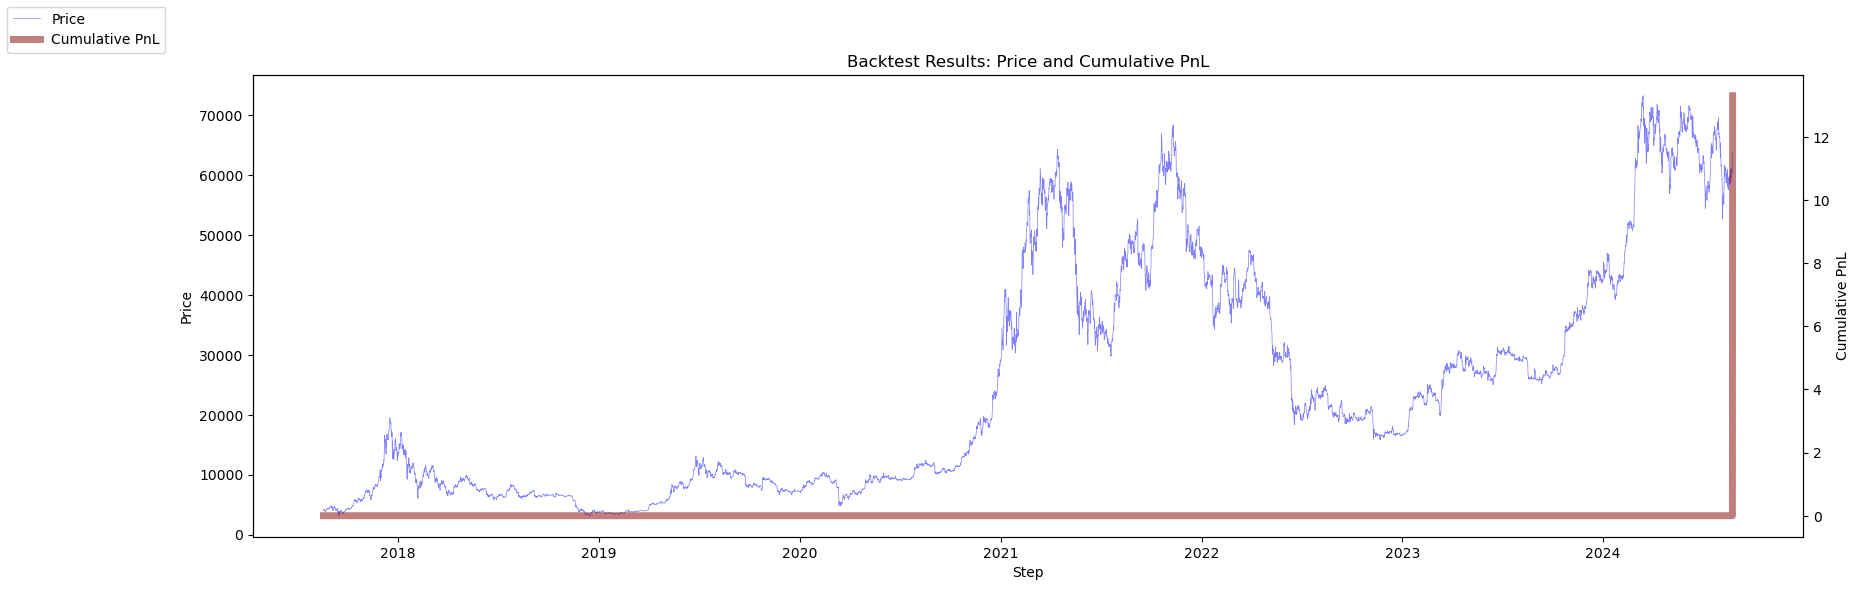

                        Price Action  Position       PnL
timestamp                                               
2017-08-18 08:00:00   4235.89      1         1   0.00000
2017-08-18 16:00:00   4107.37      1         1   0.00000
2017-08-19 00:00:00   4032.47      1         1   0.00000
2017-08-19 08:00:00   3971.05      1         1   0.00000
2017-08-19 16:00:00   4138.98      1         1   0.00000
...                       ...    ...       ...       ...
2024-08-22 08:00:00  60406.40      1         1   0.00000
2024-08-22 16:00:00  60374.84      1         1   0.00000
2024-08-23 00:00:00  61068.27      1         1   0.00000
2024-08-23 08:00:00  61532.05      1         1   0.00000
2024-08-23 16:00:00  63626.74      1         0  13.30918

[7688 rows x 4 columns]


In [58]:
# Example of running the backtest
results = backtest(env, lookback_window_size=lookback_window_size, model=model, render=False)
plot_results(results)


In [16]:
results.Action.value_counts()

Action
0    7687
1       1
Name: count, dtype: int64